# Mini Projeto 1

Análise de Vendas Para Loja de E-commerce com NumPy, Pandas e Matplotlib

## 1. Definição do Problema de Negócio Proposto Pela DSA

**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

- Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

- Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

- Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

- Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

## 2. Importação das Bibliotecas

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime, timedelta
import matplotlib.ticker as mticker

In [103]:
# Exibir gráficos diretamente no notebook

%matplotlib inline

## 3. Função Para Geração de Dados Fictícios

Para fins de replicar os resultados obtidos pela DSA, foi utilizada a exata mesma função para geração  de dados.

In [104]:
def dsa_gera_dados_ficticios(num_registros = 600):
    
    """
    Gera um DataFrame do Pandas com dados de vendas fictícios.
    """

    # Mensagem inicial indicando a quantidade de registros a serem gerados
    print(f"\nIniciando a geração de {num_registros} registros de vendas...")

    # Dicionário com produtos, suas categorias e preços
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }

    # Cria uma lista apenas com os nomes dos produtos
    lista_produtos = list(produtos.keys())

    # Dicionário com cidades e seus respectivos estados
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    # Cria uma lista apenas com os nomes das cidades
    lista_cidades = list(cidades_estados.keys())

    # Lista que armazenará os registros de vendas
    dados_vendas = []

    # Define a data inicial dos pedidos
    data_inicial = datetime(2026, 1, 1)

    # Loop para gerar os registros de vendas
    for i in range(num_registros):
        
        # Seleciona aleatoriamente um produto
        produto_nome = random.choice(lista_produtos)

        # Seleciona aleatoriamente uma cidade
        cidade = random.choice(lista_cidades)

        # Gera uma quantidade de produtos vendida entre 1 e 7
        quantidade = np.random.randint(1, 8)

        # Calcula a data do pedido a partir da data inicial
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        # Se o produto for Mouse ou Teclado, aplica desconto aleatório de até 10%
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']

        # Adiciona um registro de venda à lista
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })
    
    # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    # Retorna os dados no formato de DataFrame
    return pd.DataFrame(dados_vendas)

## 4. Gerar, Carregar e Explorar os Dados

### 4.1 Gerando os Dados Chamando a Função Criada Anteriormente

In [105]:
df_vendas = dsa_gera_dados_ficticios(500)


Iniciando a geração de 500 registros de vendas...
Geração de dados concluída.



### 4.2 Análise Exploratória dos Dados

In [106]:
df_vendas.head(50)

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 03:00:00,Mouse Vertical,Acessórios,234.96,5,109,Salvador,BA
1,1001,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.00,6,130,Rio de Janeiro,RJ
2,1002,2026-01-01 14:00:00,Headset 7.1,Acessórios,800.00,2,132,Curitiba,PR
3,1003,2026-01-01 15:00:00,Cadeira Gamer,Móveis,1200.00,4,124,Salvador,BA
4,1004,2026-01-01 02:00:00,Monitor Ultrawide,Eletrônicos,2800.00,5,131,Rio de Janeiro,RJ
5,1005,2026-01-02 07:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,113,Belo Horizonte,MG
6,1006,2026-01-02 02:00:00,SSD 1TB,Hardware,600.00,7,116,Rio de Janeiro,RJ
7,1007,2026-01-02 00:00:00,Cadeira Gamer,Móveis,1200.00,5,122,Belo Horizonte,MG
8,1008,2026-01-02 12:00:00,Headset 7.1,Acessórios,800.00,7,126,Curitiba,PR
9,1009,2026-01-02 18:00:00,Laptop Gamer,Eletrônicos,7500.00,1,109,Salvador,BA


In [107]:
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

In [108]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [109]:
df_vendas.isnull().sum()

ID_Pedido         0
Data_Pedido       0
Nome_Produto      0
Categoria         0
Preco_Unitario    0
Quantidade        0
ID_Cliente        0
Cidade            0
Estado            0
dtype: int64

In [110]:
df_vendas.isna().sum()

ID_Pedido         0
Data_Pedido       0
Nome_Produto      0
Categoria         0
Preco_Unitario    0
Quantidade        0
ID_Cliente        0
Cidade            0
Estado            0
dtype: int64

In [111]:
df_vendas.shape

(500, 9)

In [112]:
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.00000,500.000000,500.000000
mean,1249.500000,2026-02-19 23:13:12,2354.27664,3.954000,124.146000
min,1000.000000,2026-01-01 02:00:00,225.23000,1.000000,100.000000
25%,1124.750000,2026-01-26 04:15:00,548.52000,2.000000,111.000000
50%,1249.500000,2026-02-20 01:00:00,1200.00000,4.000000,124.000000
75%,1374.250000,2026-03-16 21:15:00,4500.00000,6.000000,137.000000
max,1499.000000,2026-04-10 20:00:00,7500.00000,7.000000,149.000000
std,144.481833,NaN,2458.22578,1.916044,14.624378


## 5. Limpeza, Pré-Processamento e Engenharia de Atributos

### 5.1 Criando uma cópia do DataFrame

In [113]:
df1 = df_vendas.copy()

In [114]:
df1.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 03:00:00,Mouse Vertical,Acessórios,234.96,5,109,Salvador,BA
1,1001,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.00,6,130,Rio de Janeiro,RJ
2,1002,2026-01-01 14:00:00,Headset 7.1,Acessórios,800.00,2,132,Curitiba,PR
3,1003,2026-01-01 15:00:00,Cadeira Gamer,Móveis,1200.00,4,124,Salvador,BA
4,1004,2026-01-01 02:00:00,Monitor Ultrawide,Eletrônicos,2800.00,5,131,Rio de Janeiro,RJ


### 5.2 Alterando os Dtypes

In [115]:
df1.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

In [116]:
# Data_Pedido
df1['Data_Pedido'] = pd.to_datetime(df1['Data_Pedido'])
df1['Data_Pedido'].dtype

dtype('<M8[ns]')

In [117]:
# Nome_Produto
df1['Nome_Produto'] = df1['Nome_Produto'].astype("string")
df1['Nome_Produto'].dtype

string[python]

In [118]:
# Categoria
df1['Categoria'] = df1['Categoria'].astype("string")
df1['Categoria'].dtype

string[python]

In [119]:
# Cidade
df1['Cidade'] = df1['Cidade'].astype("string")
df1['Cidade'].dtype

string[python]

In [120]:
# Estado
df1['Estado'] = df1['Estado'].astype("string")
df1['Estado'].dtype

string[python]

In [121]:
df1.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto      string[python]
Categoria         string[python]
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade            string[python]
Estado            string[python]
dtype: object

### 5.3 Engenharia de Atributos

In [122]:
# Criando uma coluna de faturamento total, que é o preço unitário multiplicado pela quantidade vendida
df1["Faturamento"] = df1["Preco_Unitario"] * df1["Quantidade"]

In [123]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    string        
 3   Categoria       500 non-null    string        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    string        
 8   Estado          500 non-null    string        
 9   Faturamento     500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(3), string(4)
memory usage: 39.2 KB


## 6. Análises

### 6.1 Análise 1 - Top 10 Produtos Mais Vendidos

In [124]:
df1.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento
0,1000,2026-01-01 03:00:00,Mouse Vertical,Acessórios,234.96,5,109,Salvador,BA,1174.8
1,1001,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.00,6,130,Rio de Janeiro,RJ,7200.0
2,1002,2026-01-01 14:00:00,Headset 7.1,Acessórios,800.00,2,132,Curitiba,PR,1600.0
3,1003,2026-01-01 15:00:00,Cadeira Gamer,Móveis,1200.00,4,124,Salvador,BA,4800.0
4,1004,2026-01-01 02:00:00,Monitor Ultrawide,Eletrônicos,2800.00,5,131,Rio de Janeiro,RJ,14000.0


In [125]:
top10 = df1.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [126]:
top10

Nome_Produto
Laptop Gamer         280
SSD 1TB              269
Teclado Mecânico     251
Cadeira Gamer        240
Placa de Vídeo       237
Headset 7.1          234
Monitor Ultrawide    234
Mouse Vertical       232
Name: Quantidade, dtype: int64

### 6.1.1 Gráfico 1 - Top 10 Produtos Mais Vendidos

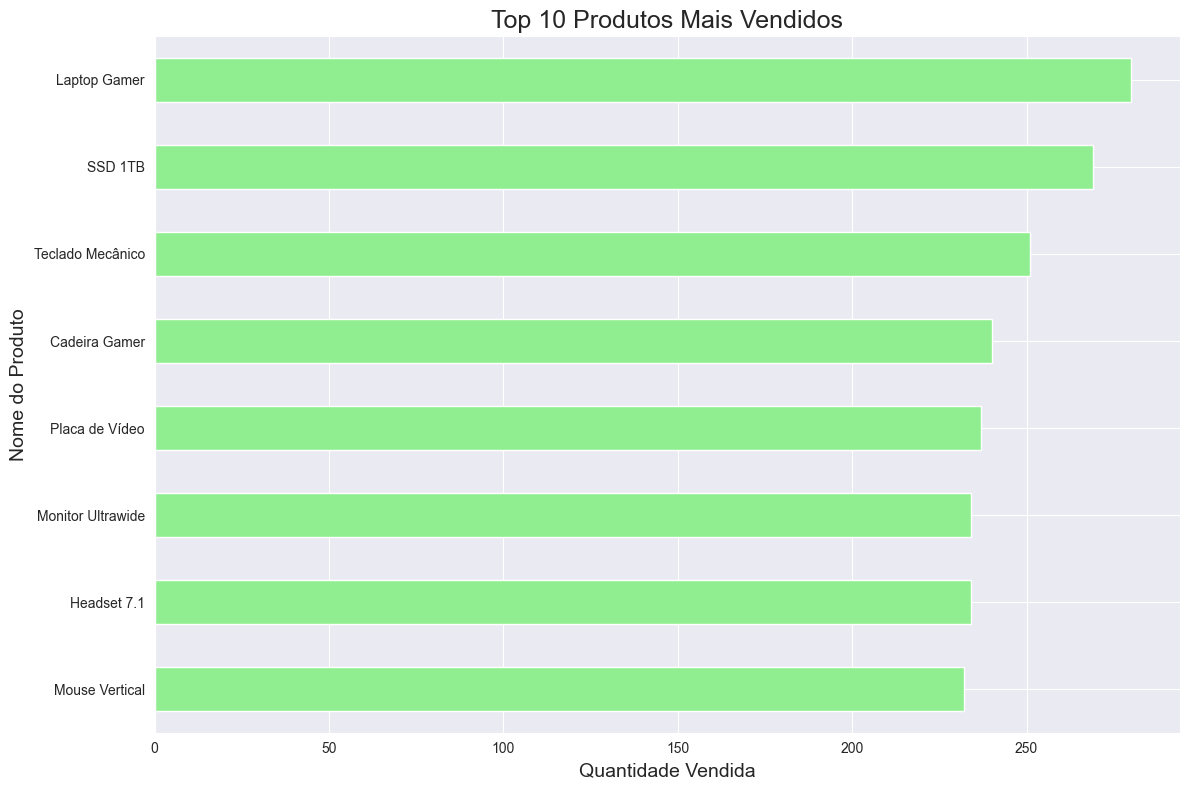

In [127]:
sns.set_style("darkgrid")

plt.figure(figsize = (12, 8))

top10.sort_values(ascending = True).plot(kind = 'barh', color = 'lightgreen')

plt.title("Top 10 Produtos Mais Vendidos", fontsize = 18)
plt.xlabel("Quantidade Vendida", fontsize = 14)
plt.ylabel("Nome do Produto", fontsize = 14)

plt.tight_layout()
plt.show()

### 6.2 Análise 2 - Faturamento Mensal

In [128]:
df1.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento
0,1000,2026-01-01 03:00:00,Mouse Vertical,Acessórios,234.96,5,109,Salvador,BA,1174.8
1,1001,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.00,6,130,Rio de Janeiro,RJ,7200.0
2,1002,2026-01-01 14:00:00,Headset 7.1,Acessórios,800.00,2,132,Curitiba,PR,1600.0
3,1003,2026-01-01 15:00:00,Cadeira Gamer,Móveis,1200.00,4,124,Salvador,BA,4800.0
4,1004,2026-01-01 02:00:00,Monitor Ultrawide,Eletrônicos,2800.00,5,131,Rio de Janeiro,RJ,14000.0


In [129]:
df1["Mes"] = df1["Data_Pedido"].dt.to_period("M")

In [130]:
df1.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto      string[python]
Categoria         string[python]
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade            string[python]
Estado            string[python]
Faturamento              float64
Mes                    period[M]
dtype: object

In [131]:
df1.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Mes
0,1000,2026-01-01 03:00:00,Mouse Vertical,Acessórios,234.96,5,109,Salvador,BA,1174.8,2026-01
1,1001,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.00,6,130,Rio de Janeiro,RJ,7200.0,2026-01
2,1002,2026-01-01 14:00:00,Headset 7.1,Acessórios,800.00,2,132,Curitiba,PR,1600.0,2026-01
3,1003,2026-01-01 15:00:00,Cadeira Gamer,Móveis,1200.00,4,124,Salvador,BA,4800.0,2026-01
4,1004,2026-01-01 02:00:00,Monitor Ultrawide,Eletrônicos,2800.00,5,131,Rio de Janeiro,RJ,14000.0,2026-01


In [132]:
faturamento_mensal = df1.groupby("Mes")["Faturamento"].sum().sort_index()

In [133]:
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [134]:
faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,450,273.09
2026-02    R$ 1,131,840.66
2026-03    R$ 1,586,207.61
2026-04      R$ 475,654.65
Name: Faturamento, dtype: object

### 6.2.1 Gráfico 2 - Gráfico de Barras do Faturamento Mensal

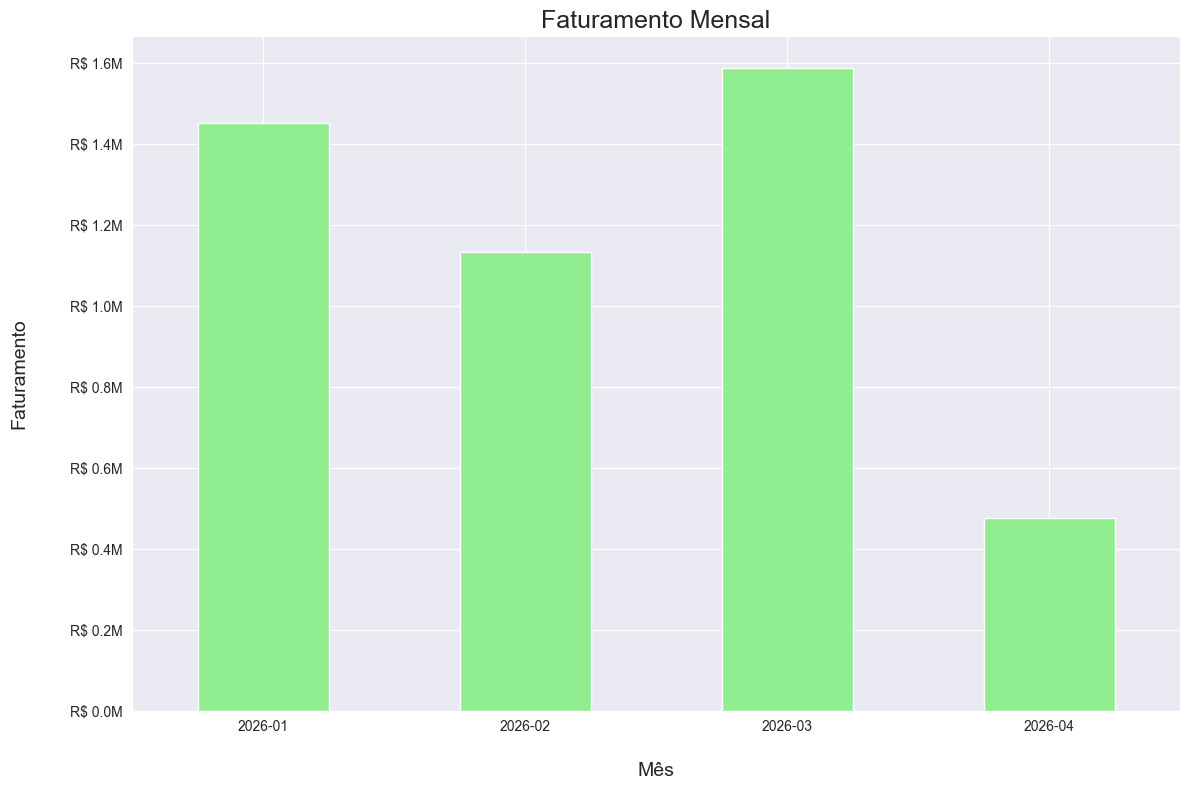

In [135]:
plt.figure(figsize=(12, 8))

ax = faturamento_mensal.plot(
    kind='bar',
    color='lightgreen'
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:,.1f}M')
)

plt.title("Faturamento Mensal", fontsize=18)

plt.xlabel("Mês", fontsize=14, labelpad=20)
plt.ylabel("Faturamento", fontsize=14, labelpad=30)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.2.1 Gráfico 3 - Gráfico de Linha do Faturamento Mensal

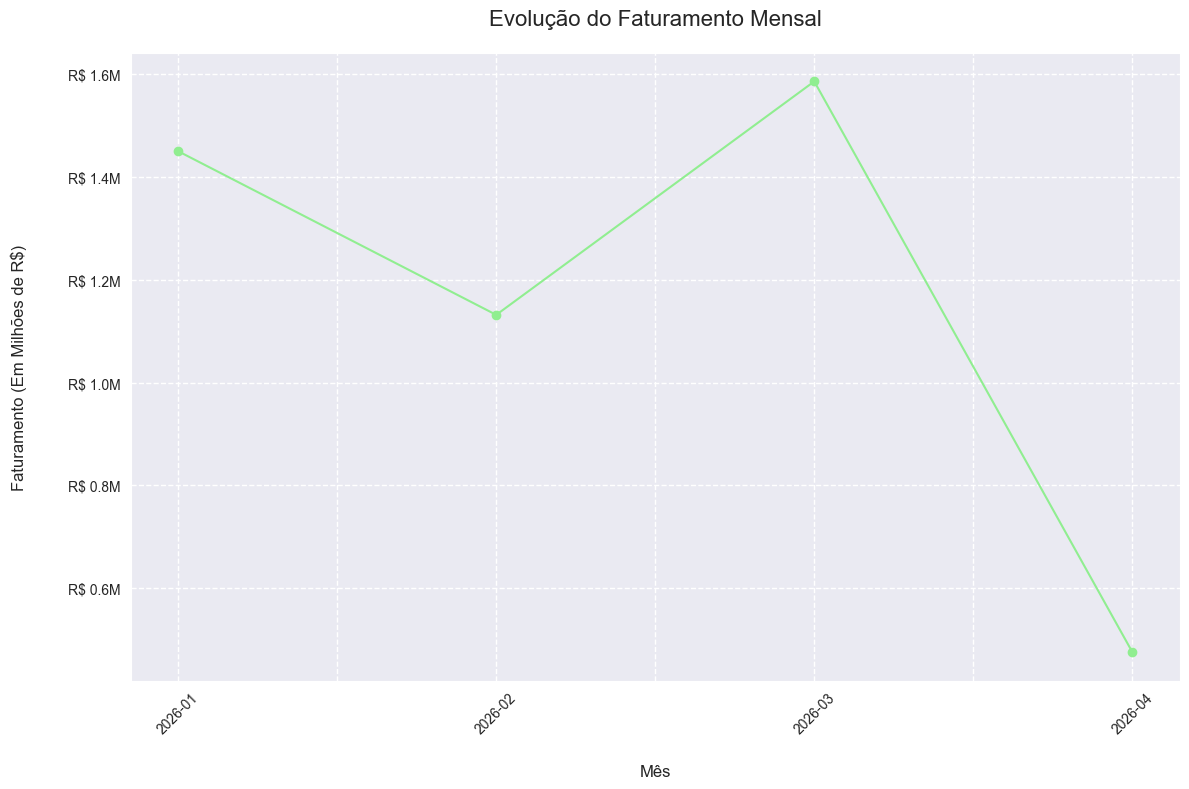

In [136]:
plt.figure(figsize = (12, 8))

ax = faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'lightgreen')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:,.1f}M')
)

plt.title('Evolução do Faturamento Mensal', fontsize = 16, pad = 20)

plt.xlabel('Mês', fontsize = 12, labelpad = 20)
plt.ylabel('Faturamento (Em Milhões de R$)', fontsize = 12, labelpad = 30)


plt.xticks(rotation = 45)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 1)

plt.tight_layout()

plt.show()

### 6.3 Análise 3 - Vendas por Estado

In [137]:
df1.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Mes
0,1000,2026-01-01 03:00:00,Mouse Vertical,Acessórios,234.96,5,109,Salvador,BA,1174.8,2026-01
1,1001,2026-01-01 08:00:00,Cadeira Gamer,Móveis,1200.00,6,130,Rio de Janeiro,RJ,7200.0,2026-01
2,1002,2026-01-01 14:00:00,Headset 7.1,Acessórios,800.00,2,132,Curitiba,PR,1600.0,2026-01
3,1003,2026-01-01 15:00:00,Cadeira Gamer,Móveis,1200.00,4,124,Salvador,BA,4800.0,2026-01
4,1004,2026-01-01 02:00:00,Monitor Ultrawide,Eletrônicos,2800.00,5,131,Rio de Janeiro,RJ,14000.0,2026-01


In [138]:
vendas_estado = df1.groupby("Estado")["Faturamento"].sum().sort_index()

In [139]:
vendas_estado.map('R$ {:,.2f}'.format)

Estado
BA    R$ 606,460.23
CE    R$ 494,817.54
MG    R$ 754,422.54
PR    R$ 661,472.10
RJ    R$ 761,400.32
RS    R$ 684,257.57
SP    R$ 681,145.71
Name: Faturamento, dtype: object

In [140]:
vendas_sorted = vendas_estado.sort_values(ascending=True)

### 6.3.1 Gráfico 4 - Vendas por Estado

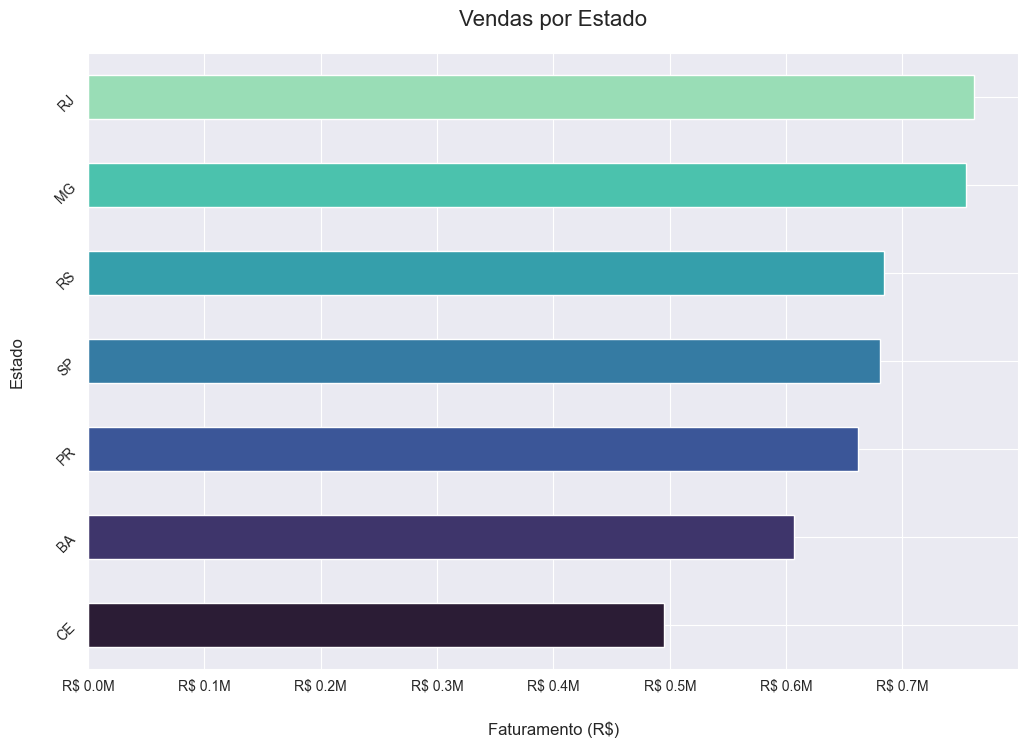

In [141]:
plt.figure(figsize = (12,8))

ax = vendas_sorted.plot(
    kind = 'barh', 
    color = sns.color_palette("mako", n_colors = len(vendas_sorted))
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:,.1f}M')
)

plt.title('Vendas por Estado', fontsize = 16, pad = 20)

plt.xlabel('Faturamento (R$)', fontsize = 12, labelpad = 20)
plt.ylabel('Estado', fontsize = 12, labelpad = 20)

plt.yticks(rotation = 45)

plt.show()

### 6.4 Análise 4 - Faturamento por Categoria

In [142]:
faturamento_categoria = df1.groupby("Categoria")["Faturamento"].sum().sort_index(ascending = False)

In [143]:
faturamento_categoria = faturamento_categoria.sort_values(ascending = False)

In [144]:
faturamento_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 2,755,200.00
Hardware       R$ 1,227,900.00
Acessórios       R$ 372,876.01
Móveis           R$ 288,000.00
Name: Faturamento, dtype: object

In [145]:
faturamento_categoria

Categoria
Eletrônicos    2755200.00
Hardware       1227900.00
Acessórios      372876.01
Móveis          288000.00
Name: Faturamento, dtype: float64

### 6.4.1 Gráfico 5 - Vendas por Estado

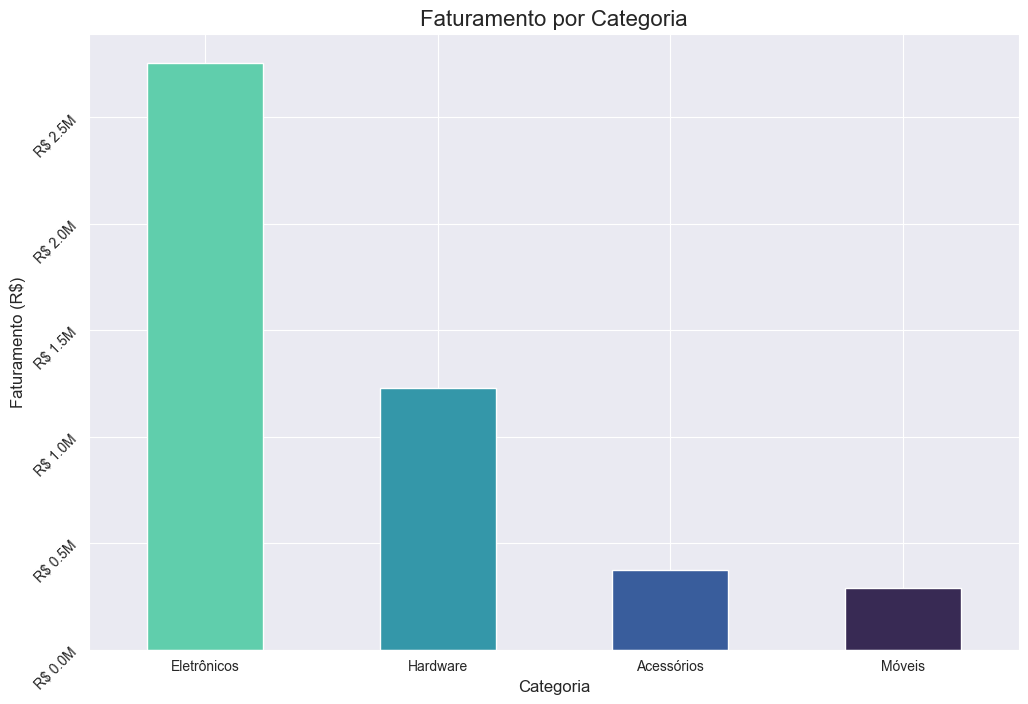

In [146]:
plt.figure(figsize = (12,8))

ax = faturamento_categoria.plot(
    kind = 'bar', 
    color = sns.color_palette("mako_r", n_colors = len(faturamento_categoria))
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'R$ {x/1e6:,.1f}M')
)

plt.title('Faturamento por Categoria', fontsize = 16)

plt.xlabel('Categoria', fontsize = 12)
plt.ylabel('Faturamento (R$)', fontsize = 12)

plt.xticks(rotation = 0)
plt.yticks(rotation = 45)

plt.show()

## 7. Análises Adicionais

### 7.1 Produtos que Mais Geram Faturamento

In [147]:
top_faturamento = df1.groupby('Nome_Produto')['Faturamento'].sum().sort_values(ascending = True).head(10)

In [148]:
top_faturamento

Nome_Produto
Mouse Vertical         55292.37
Teclado Mecânico      130383.64
SSD 1TB               161400.00
Headset 7.1           187200.00
Cadeira Gamer         288000.00
Monitor Ultrawide     655200.00
Placa de Vídeo       1066500.00
Laptop Gamer         2100000.00
Name: Faturamento, dtype: float64

### 7.1.1 Gráfico 6 - Produtos que Mais Geram Faturamento

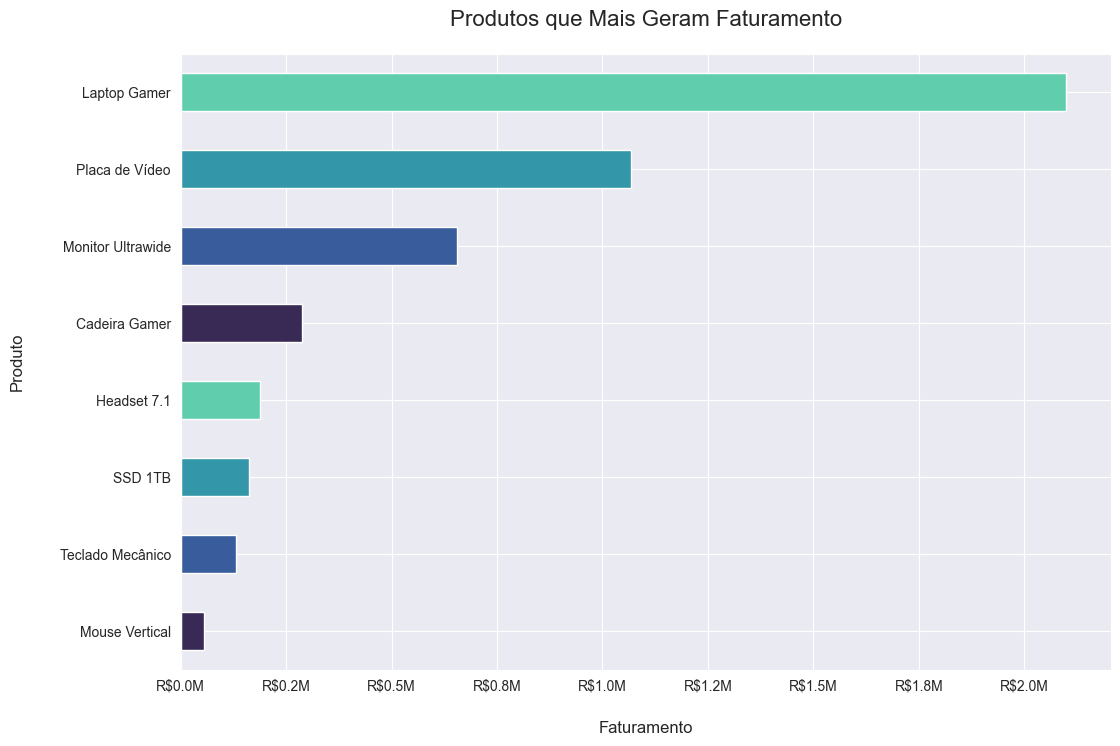

In [149]:
plt.figure(figsize = (12,8))

ax = top_faturamento.plot(
    kind = 'barh',
    color = sns.color_palette("mako", n_colors = len(faturamento_categoria))
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f'R${x/1e6:,.1f}M')
)

plt.title('Produtos que Mais Geram Faturamento', fontsize = 16, pad = 20)

plt.xlabel('Faturamento', fontsize = 12, labelpad = 20)
plt.ylabel('Produto', fontsize = 12, labelpad = 25)

plt.show()

### 7.2 Quantidade Vendida por Categoria

In [150]:
quantidade_categoria = df1.groupby("Categoria")["Quantidade"].sum().sort_values(ascending = False)

In [151]:
quantidade_categoria

Categoria
Acessórios     717
Eletrônicos    514
Hardware       506
Móveis         240
Name: Quantidade, dtype: int64

### 7.2.1 Gráfico 7 - Quantidade Vendida por Categoria

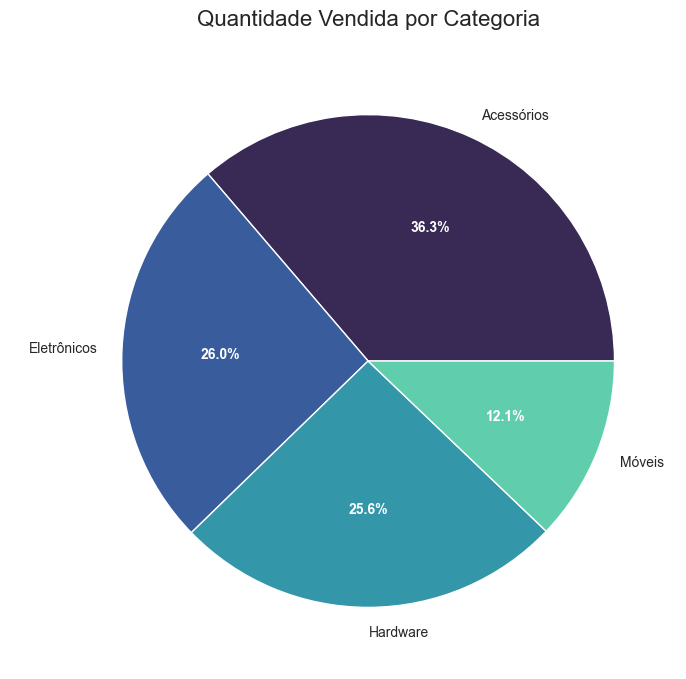

In [152]:
plt.figure(figsize=(12, 8))

ax = quantidade_categoria.plot(
    kind='pie',
    colors=sns.color_palette("mako", n_colors=len(quantidade_categoria)),
    autopct='%1.1f%%'
)

plt.title('Quantidade Vendida por Categoria', fontsize=16, pad=20)
plt.ylabel(' ', labelpad = 26)

for text in ax.texts:
    if '%' in text.get_text():
        text.set_color('white')
        text.set_fontweight('bold')

plt.show()

### 7.2.2 Gráfico 8 - Quantidade Vendida por Categoria

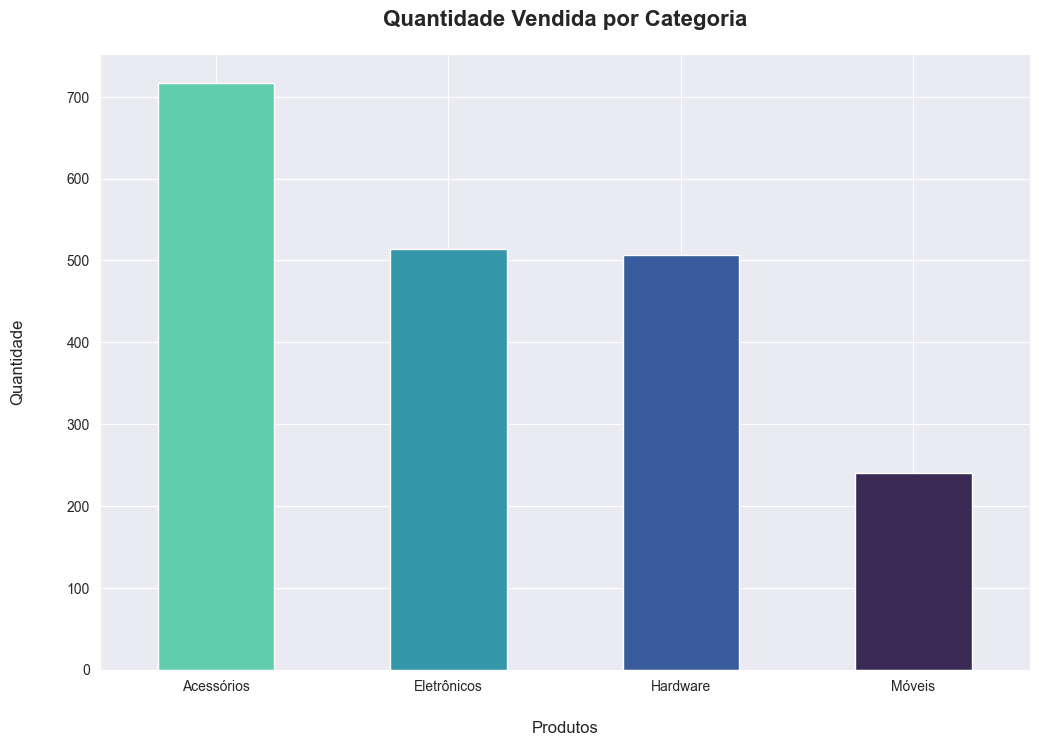

In [163]:
plt.figure(figsize = (12,8))

quantidade_categoria.plot(
    kind = 'bar',
    color = sns.color_palette('mako_r', n_colors = len(quantidade_categoria))
)

plt.title('Quantidade Vendida por Categoria', fontsize = 16, fontweight = 'bold', pad = 20)

plt.xlabel('Produtos', fontsize = 12, labelpad = 20)
plt.ylabel('Quantidade', fontsize = 12, labelpad = 30)

plt.xticks(rotation = 0)

plt.show()